# 13 · Tous les réglages : 2018 ou les années simulées

Jusqu'à l'étape 11, presque tous les réglages de la chaîne ont été choisis en regardant 2018, l'année
qu'on note ensuite. Les carnets 05 à 11 les ont réglés une seconde fois sur les 12 années simulées de
l'étape 12, chacun dans sa section « Réglé sur les années simulées ». Ce carnet met tout ensemble :

1. **l'inventaire** : chaque réglage, où et sur quoi il a été choisi, et s'il peut changer les alarmes ;
2. **les choix**, grille par grille, dans l'ordre de la chaîne ;
3. **la comparaison finale** : la chaîne entièrement réglée sur 2018 contre la chaîne entièrement réglée
   sur les années simulées, notées sur 2018 et sur les 12 années simulées ;
4. **chaque réglage seul** : ce que coûte ou rapporte sur 2018 le fait de prendre sa valeur des
   simulées, en σ du hasard ;
5. **la stabilité** des choix quand on retire les 3 années d'une variante.

**Temps de calcul** (mesurés sur 16 cœurs ; compter environ le double sur 8) : environ 1 minute si les carnets 05 à 11 ont déjà tourné (ce carnet relit leurs grilles dans `sorties/`) ; sinon environ 10 minutes de plus, surtout pour la grille des CUSUM.

## Réglages utilisés

In [1]:
import sys; sys.path.insert(0, "..")
import os
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

from etapes import reglages as G, resultats as Res
from etapes.affichage import afficher
from IPython.display import display

plt.rcParams.update({"figure.figsize": (10, 3.4), "figure.dpi": 110, "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 9})
pd.set_option("display.precision", 2)
pd.set_option("display.max_colwidth", None)
from etapes import e06_chaine as Ch, e12_annees_simulees as A12, e13_regler_sur_simulees as E

afficher(G.tableau(["REGLE_SIMULEES", "GRILLES_SIMULEES", "SIGMA_SIMULEES", "SIGMA_DUAL_SIMULEES", "PENTE_SIMULEES"]), 0)

,valeur,unité,ce qu'il contrôle,origine
REGLE_SIMULEES,"CUSUM 8/6 et 3/10, pause 48 h, lecture 24 h et 7 j, sans limite d'amplitude, visible 0,25 cm, abstention, carte de pression, confirmer les alarmes de débit (0,25 m³/h en 96 h), sans regroupement",,la chaîne entière réglée sur les années simulées (carnet 13),"chaque réglage : le plus d'euros en tout sur les 12 années simulées, dans l'ordre de la chaîne, les CUSUM et la lecture refaits jusqu'à ce qu'un tour ne change plus rien"
GRILLES_SIMULEES,voir reglages.py,,"les grilles essayées pour chaque réglage, sur 2018 et sur les années simulées (carnets 05 à 13)","choix, prolongées tant que le meilleur tombait au bord, d'un côté ou de l'autre"
SIGMA_SIMULEES,"1,02 cm ; 0,21","cm, part","σ et partie relative de la carte de pression, réglés sur les années simulées","comme l'étape 05 (écart médian à la bonne conduite), sur les fuites des 12 années simulées ; ne change pas les alarmes (carnet 05)"
SIGMA_DUAL_SIMULEES,"0,69 m³/h ; 0,36","m³/h, part","σ et partie relative de la carte du dual, réglés sur les années simulées","comme l'étape 11, sur les fuites des 12 années simulées ; ne change pas les alarmes (carnet 11)"
PENTE_SIMULEES,"A+B −0,888 ; C −2,80",cm par m³/h,"la pente résidu contre fuite, pour fondre les signaux ou confirmer une alarme de débit par la pression","la droite de l'étape 01 sur les jours des 12 années simulées (2018 : −0,90 et −2,90)"


In [2]:
import os
from etapes import e06_chaine as Ch, e12_annees_simulees as A12, e13_regler_sur_simulees as E
P = os.cpu_count()
ref12 = A12.reference_2018(P)          # ce que la chaîne garde de 2018 (dictionnaires, distances)
a18 = E.annee_2018(ref12, P)
ans = E.annees_simulees(ref12, P)      # les 12 années de l'étape 12 (fabriquées la première fois)
r18 = E.Reglages()                     # la chaîne réglée sur 2018 (la version finale de l'étape 11)
rsim = E.reglages_simules()            # la chaîne réglée sur les simulées, étape par étape (carnet 13)

## 1. L'inventaire

Chaque réglage de la chaîne qui a été choisi, avec ce qui a servi à le choisir. « Change les alarmes ? »
dit si une autre valeur peut changer les alarmes envoyées (conduite ou date). Les σ des cartes ne le
peuvent pas : la conduite envoyée est celle qui colle le mieux, quel que soit σ (vérifié aux carnets 05
et 11 sur 2018 et sur les 12 années).

In [3]:
afficher(E.inventaire(), 0)

,étape,choisi par,choisi sur,change les alarmes ?,réglé sur les simulées
réglage,,,,,
"CANDIDATS_CUSUM (2/24, 3/12, 3/18)",02,"front de Pareto : fausses alarmes contre retard médian, toutes les fuites vues",2018,oui : le couple de l'étape 06 est pris parmi eux,carnet 06 : toute la grille
"CANDIDATS_DEBIT (1,5/40, 1,5/80, 3/10)",03,"idem, sur le bilan",2018,oui (idem),carnet 06 : toute la grille
"CHOIX_CUSUM, CHOIX_DEBIT (3/18, 3/10)",06,"euros, parmi les 3 × 3 candidats",2018,oui,carnet 06 (déjà en phase 2 parmi les candidats ; ici toute la grille)
PAUSE_H (24 h),02,"choix : égale au lissage, pas de grille",aucune donnée,oui,carnet 06
"LISSAGE_H (24 h), REFERENCE_DEPART_H (72 h), la veille (48 → 24 h)","01, 02, 05",choix,aucune donnée,oui,"non : jamais réglés, ni sur 2018 ni ici"
"RETARD_EN_PLUS_J, CROISSANCE, PART",02,choix,aucune donnée,non : ils ne servent qu'à choisir les candidats,inutile : toute la grille remplace les candidats
"SIGMA_CM (0,6 cm), SIGMA_RELATIF (0,06)",05,écart médian à la bonne conduite (`regler_sigma`),fuites de 2018,non : σ ne change pas la conduite la plus probable (vérifié),carnet 05
"PART_NETTE (0,5)",05,choix,aucune donnée,non : il ne sert qu'à régler σ,carnet 05 (avec σ)
ATTENTE_H (24 h),05,choix (dossier 04),aucune grille dans ce dossier,oui : fenêtre et date d'envoi,carnet 05


## 2. Les choix, grille par grille

Dans l'ordre de la chaîne. Pour chaque grille : le réglage de 2018 (celui de ce dossier), le meilleur sur
2018 dans la même grille (s'il avait été cherché ainsi), le réglage des années simulées, s'il tombe au
bord de la grille (après prolongement), et combien des 4 choix « sans une variante » le gardent. Les
grilles elles-mêmes sont dans les carnets 05 à 11 (et dans `sorties/simulees_p3_*.csv`).

In [4]:
choix = E.resume_des_choix(a18, ans, ref12, r18, rsim, P)
afficher(choix, 0)

,réglé sur 2018,meilleur sur 2018 (même grille),réglé sur les simulées,au bord ?,gardé sans une variante
cusum,"3/18, 3/10, 24","2.5/3, 3/5, 48","8/6, 3/10, 48",non,1 / 4
attente_h,24,6,24,non,3 / 4
semaines_j,7,7,7,non,2 / 4
amplitude_max,5,1e+06,1e+06,amplitude_max (haut),4 / 4
visible_cm,0.5,0.25,0.25,non,4 / 4
abstenir,True,True,True,non,2 / 4
rayon,300,0,aucun,non,4 / 4
confirmer,pression 4 24,pression 2 12,débit 0.25 96,non,1 / 4
fusionner,2,0.125,0.125,non,3 / 4
fondre,2/40,0.25/80,0.25/80,non,2 / 4


**Ce qu'on regarde.** Les simulées gardent le réglage de 2018 pour ATTENTE_H, SEMAINES_J, l'abstention et la façon
de combiner (confirmer). Elles changent les CUSUM (8/6 au lieu de 3/18, pause de 48 h), la limite
d'amplitude (aucune, mêmes alarmes que 8), VISIBLE_CM (0,25, mêmes alarmes que 0,5), le regroupement (aucun
au lieu de 300 m), la confirmation (les alarmes de débit au lieu de celles de pression), la fusion et le
signal fondu (qui ne servent pas dans la chaîne finale), et la carte (pression au lieu du dual). Le seul
« au bord » restant est AMPLITUDE_MAX, où « sans limite » est une vraie borne. La colonne « meilleur sur
2018 » montre ce que 2018 aurait choisi seule dans les mêmes grilles : souvent autre chose que les
simulées, et souvent autre chose que ce que ce dossier a gardé.

## 3. La comparaison finale

Deux chaînes complètes : **réglée sur 2018** (la version finale de l'étape 11 : CUSUM 3/18 et 3/10,
lecture du dossier 04, abstention, dual, confirmation, regroupement à 300 m) et **réglée sur les années
simulées** (tous les choix ci-dessus). Chacune est notée sur 2018 et sur la somme des 12 années
simulées.

In [5]:
versions = {"réglé sur 2018": r18, "réglé sur les simulées": rsim}
lf = E.lignes_completes(a18, ans, ref12, versions, "11", P)
afficher(E.tableau(lf), 1)

,N,trouvées,fausses,fausses : détecteur,fausses : localisation,euros,hasard ± σ (€),z
règle,,,,,,,,
réglé sur 2018 → noté sur 2018,15,13 / 14,2,2,0,151681,22 767 ± 22 537,5.7
réglé sur les simulées → noté sur 2018,38,13 / 14,11,1,10,140422,50 393 ± 21 104,4.3
réglé sur 2018 → somme des 12 années simulées,181,75 / 181,103,57,46,1574392,438 429 ± 138 796,8.2
réglé sur les simulées → somme des 12 années simulées,582,127 / 181,213,79,134,2674382,1 259 675 ± 135 751,10.4


**Ce qu'on regarde.** Sur 2018 : **−11 259 € (−0,50 σ)**, les mêmes 13 fuites, 38 alarmes au lieu de 15 (11 fausses
au lieu de 2). Sur les simulées : +1 099 990 € (+70 %), 127 fuites sur 181 au lieu de 75. Attention : sur les
simulées, la ligne « réglé sur les simulées » est notée sur les années qui ont servi à la régler ; son avance
y est optimiste. 2018 est la seule note hors échantillon pour la chaîne des simulées ; pour celle de 2018,
c'est l'inverse : les simulées sont sa validation.

Par classe de fuite, sur les 12 années simulées :

In [6]:
afficher(E.classes_par_version(ans, ref12, versions, "11"), 2)

**Ce qu'on regarde.** Sur les simulées, la chaîne de 2018 trouve 30 à 59 % des fuites selon la classe, celle des
simulées 50 à 96 %. Les retards sont du même ordre, souvent plus courts pour la chaîne des simulées (heures
pour les casses, jours pour les fuites qui grandissent).

## 4. Chaque réglage seul, sur 2018

On part de la chaîne réglée sur 2018 et on ne change qu'un groupe de réglages, à sa valeur des années
simulées. L'écart est donné en euros et en σ du hasard de la chaîne de 2018 (environ 20 000 €) : un
écart de moins d'un σ ne se distingue pas du hasard sur une seule année.

In [7]:
groupes = {"CUSUM et pause (02, 03, 06)": ["cusum", "debit", "pause_h"], "ATTENTE_H (05)": ["attente_h"],
           "SEMAINES_J (05)": ["semaines_j"], "AMPLITUDE_MAX (05)": ["amplitude_max"], "VISIBLE_CM (05)": ["visible_cm"],
           "s'abstenir (07)": ["abstenir"], "regrouper (08, 11)": ["rayon"],
           "combiner et ses réglages (09, 11)": ["combiner", "confirmer", "fusionner_j", "fondre", "pente"],
           "carte (11)": ["carte"], "σ des deux cartes (05, 11)": ["sigma", "sigma_dual"]}
groupes = {n: cs for n, cs in groupes.items() if any(getattr(rsim, c) != getattr(r18, c) for c in cs)}
afficher(E.un_par_un(a18, ans, ref12, r18, rsim, groupes, P), 2)

,valeur sur les simulées,2018 : N,2018 : trouvées,2018 : fausses,2018 : euros,2018 : écart (€),2018 : écart (σ du hasard),simulées : euros,simulées : écart (€)
réglé sur 2018,,15,13,2,151681,0,0.00,1574393,0
"CUSUM et pause (02, 03, 06)","cusum = 8/6, debit = 3/10, pause_h = 48",15,12,3,145294,-6387,-0.28,1531839,-42554
AMPLITUDE_MAX (05),amplitude_max = 1e+06,15,13,2,151681,0,0.00,1574393,0
VISIBLE_CM (05),visible_cm = 0.25,15,13,2,151681,0,0.00,1574393,0
"regrouper (08, 11)",rayon = aucun,44,13,8,148681,-3000,-0.13,2604481,1030087
"combiner et ses réglages (09, 11)","combiner = confirmer, confirmer = débit 0.25 96, fusionner_j = 0.125, fondre = 0.25/80, pente = AB=-0.8876 C=-2.805",16,11,4,134351,-17330,-0.77,1783678,209285
carte (11),carte = pression,15,11,4,135273,-16408,-0.73,1807301,232907
"σ des deux cartes (05, 11)","sigma = 1.02/0.21, sigma_dual = 0.69/0.36",15,13,2,151681,0,0.00,1574393,0


**Ce qu'on regarde.** Seuls les groupes dont la valeur change sont montrés. Aucun réglage pris seul ne fait gagner 2018. Trois en coûtent : la confirmation des
alarmes de débit au lieu de celles de pression (−17 330 €, −0,77 σ), la carte de pression au lieu du dual
(−16 408 €, −0,73 σ) et les CUSUM (−6 387 €, −0,28 σ). Ne pas regrouper coûte 3 000 € sur 2018 (−0,13 σ)
mais rapporte 1 030 087 € sur les simulées (+65 %) : c'est l'essentiel de l'écart entre les deux chaînes sur
les simulées. Les σ, l'amplitude et VISIBLE_CM ne changent rien. Aucun écart n'atteint 1 σ du hasard.

## 5. La stabilité

Pour chaque grille, le choix refait sans les 3 années d'une variante (à réglages d'avant fixés).

In [8]:
stab = {}
for nom in E.grilles_p3():
    t18, tsim = E.grilles_etape(nom, a18, ans, ref12, r18, rsim, P)
    x = E.grilles_p3()[nom][2]
    champs = [c for c in tsim.index.names[1:] if not (x and c == "combiner")]
    s_ = E.sans_une_variante(tsim)
    stab[nom] = s_.map(lambda k: ", ".join(v for c, v in zip(tsim.index.names[1:], k if isinstance(k, tuple) else (k,))
                                           if c in champs))
afficher(pd.DataFrame(stab).T, 0)

,toutes les années,sans la variante v0,sans la variante v1,sans la variante v2,sans la variante v3
cusum,"8/6, 3/10, 48","10/18, 3/10, 48","3/48, 3/120, 24","5/72, 2/160, 72","8/6, 3/10, 48"
attente_h,24,36,24,24,24
semaines_j,7,7,5,14,7
amplitude_max,1e+06,1e+06,1e+06,1e+06,1e+06
visible_cm,0.25,0.25,0.25,0.25,0.25
abstenir,True,True,True,False,False
rayon,aucun,aucun,aucun,aucun,aucun
confirmer,débit 0.25 96,débit 0.5 96,débit 0.5 72,débit 1 72,débit 0.25 96
fusionner,0.125,0.125,0.125,0.25,0.125
fondre,0.25/80,1.5/40,0.25/80,1.5/80,0.25/80


**Ce qu'on regarde.** Stables (4 sur 4) : l'amplitude, VISIBLE_CM, le regroupement (« aucun ») et la façon
de combiner (confirmer). À moitié : ATTENTE_H (3 sur 4), la fusion (3 sur 4), SEMAINES_J, l'abstention et le
signal fondu (2 sur 4). Instables : les CUSUM (une réponse différente à chaque variante retirée), la
confirmation (toujours les alarmes de débit, mais X de 0,25 à 1 m³/h et H de 72 à 96 h) et la version
finale (deux fois le dual avec un rayon de 0 m, deux fois la pression sans regroupement).

## 6. La chaîne retenue

La chaîne retenue est celle de l'étape 11 (réglée sur 2018 : CUSUM 3/18 et 3/10, lecture du dossier 04,
abstention, carte du dual, alarmes de pression confirmées par le bilan) **sans le regroupement à 300 m**
(`CHOIX_REGROUPER = False`). C'est le seul réglage de la chaîne de 2018 qu'on change : en partie 2, le
regroupement n'est jamais choisi sur les années simulées, même en retirant tour à tour chacune des 4
variantes.

Attention : cette décision a été prise en regardant les 12 années simulées. Notée sur ces mêmes années,
la chaîne retenue n'est donc pas tout à fait hors échantillon (un seul réglage, oui ou non, a vu ces
années ; tous les autres viennent de 2018).

In [9]:
versions_r = {"réglée sur 2018, avec regroupement (étape 11)": r18, "chaîne retenue : sans regroupement": E.chaine_retenue()}
lr = E.lignes_completes(a18, ans, ref12, versions_r, "11", P)
afficher(E.tableau(lr), 1)

,N,trouvées,fausses,fausses : détecteur,fausses : localisation,euros,hasard ± σ (€),z
règle,,,,,,,,
"réglée sur 2018, avec regroupement (étape 11) → noté sur 2018",15,13 / 14,2,2,0,151681,22 767 ± 22 537,5.7
chaîne retenue : sans regroupement → noté sur 2018,44,13 / 14,8,3,5,148681,42 302 ± 22 568,4.7
"réglée sur 2018, avec regroupement (étape 11) → somme des 12 années simulées",181,75 / 181,103,57,46,1574392,438 429 ± 138 796,8.2
chaîne retenue : sans regroupement → somme des 12 années simulées,672,132 / 181,282,133,149,2604480,1 268 026 ± 135 065,9.9


**Ce qu'on regarde.** Sur 2018, la chaîne retenue fait **3 000 € de moins** que la chaîne avec regroupement (148 681 € contre
151 681 €, 0,13 σ du hasard), avec 44 alarmes au lieu de 15, les mêmes 13 fuites sur 14 et 8 fausses
alarmes au lieu de 2. Son z baisse plus (+5,7 → +4,7) : avec 44 alarmes, des conduites tirées au hasard
aux mêmes dates tombent plus souvent près d'une fuite, donc le hasard monte (22 767 → 42 302 €). Sur 2018,
cet écart est dans le bruit d'une seule année.

Sur les 12 années simulées, c'est l'inverse, et de loin : **2 604 480 € contre 1 574 392 €** (z +9,9
contre +8,2), 132 fuites trouvées sur 181 au lieu de 75. Le regroupement jette les alarmes envoyées à
moins de 300 m d'une alarme déjà envoyée ; sur les années simulées, beaucoup de ces alarmes trouvent une
**nouvelle** fuite proche d'une ancienne. Une fuite trouvée rapporte bien plus qu'une fausse alarme ne
coûte (500 €), donc la chaîne sans regroupement gagne, malgré 282 fausses alarmes au lieu de 103.

**Pourquoi on la garde.** Le regroupement a été choisi sur 2018 seule, l'année qu'on note ; sur 2018 il
ne gagne que 3 000 €, moins d'un dixième de σ. Sur les années simulées, il coûte 40 % des euros, et il
n'est jamais choisi, même en retirant une variante. On préfère un réglage qui tient sur 12 années à un
réglage qui gagne 3 000 € sur une seule.

Cette décision a vu les 12 années simulées : sur ces années, la chaîne retenue est donc un peu avantagée.
La partie 7 la compare à une chaîne qui, elle, n'a jamais vu les années sur lesquelles on la note.

## 7. Validation croisée par variante

**La question.** La partie 3 compare une chaîne réglée sur 2018 et une chaîne réglée sur les 12 années
simulées. Mais la chaîne des simulées est notée sur les années qui ont servi à la régler : son score sur
ces années est optimiste. Quel score attendre sur une année **qu'elle n'a pas vue** ?

**La méthode : un pli par variante.** Les 12 années viennent de 4 réseaux « vrais » (les variantes v0 à
v3), 3 années chacune. Les années d'une même variante se ressemblent (même réseau) ; on les garde donc
de côté ensemble. Pour chaque variante :

1. on prend les 9 années des 3 autres variantes ;
2. on y règle **toute la chaîne**, exactement comme en partie 2 : σ des deux cartes et pente de la fusion
   mesurés sur ces 9 années ; puis, dans l'ordre de la chaîne, les CUSUM et la pause, la lecture d'une
   alarme (refaits jusqu'à ce qu'un tour entier ne change plus rien), s'abstenir, regrouper (y compris
   « pas de regroupement »), combiner, la carte. Chaque réglage est celui qui donne le plus d'euros en
   tout sur les 9 années. Quand le meilleur réglage tombe au bord d'une grille, on la prolonge et on
   recommence ;
3. on note cette chaîne sur les 3 années gardées de côté, qu'elle n'a jamais vues.

**Les comparaisons, sur les mêmes années gardées de côté :**

- la **chaîne réglée sur 2018** (version finale de l'étape 11, avec regroupement) : elle n'a vu aucune
  année simulée, ces années sont donc hors échantillon pour elle aussi. C'est la comparaison juste ;
- la **chaîne retenue** (partie 6) : la même sans regroupement. Sa décision de ne pas regrouper vient
  de toutes les années simulées, y compris celles gardées de côté ;
- et la chaîne de chaque pli **notée sur 2018**. Les 4 chaînes ont vu des données un peu différentes :
  l'écart de leurs scores sur 2018 montre combien les réglages, et l'argent, bougent avec les données
  d'entraînement.

**Les 4 plis ensemble.** Chaque année simulée est gardée de côté une fois : on additionne les 4 plis,
soit 12 années, comme en partie 3 (comptes et euros additionnés, σ du hasard en racine de la somme des
carrés, z de la somme).

**Temps de calcul.** chaque pli se règle en 9 à 20 minutes sur 14 cœurs (v0 : 20 min, v1 : 15, v2 : 15, v3 : 9) ; les
4 plis ont tourné en même temps. Ce carnet relit les réglages de chaque pli dans
`sorties/simulees_cv_<variante>.json` et les lignes dans `sorties/simulees_cv_lignes.csv` (pour tout
refaire, effacer ces fichiers). Contrôle : la même procédure sur les 12 années redonne exactement la
chaîne des simulées de la partie 2 (18 minutes).

In [10]:
cv = {v: E.regler_un_pli(ans, ref12, v, P) for v in E.plis(ans)}
rcv = {v: E.depuis_json(d["réglages"]) for v, d in cv.items()}
for v, d in cv.items():
    print(f"pli {v} : réglé sur {', '.join(d['réglé sur'])} ; {d['secondes'] // 60} min ;",
          "grilles prolongées :", "; ".join(d["prolongements"]) or "aucune")
afficher(E.choix_des_plis({"réglée sur 2018": r18, "retenue": E.chaine_retenue(), "réglée sur les 12 années": rsim,
                           **{f"pli {v}": r for v, r in rcv.items()}}), 0)

pli v0 : réglé sur v1_a0, v1_a1, v1_a2, v2_a0, v2_a1, v2_a2, v3_a0, v3_a1, v3_a2 ; 20 min ; grilles prolongées : cusum : cusum K prolongé vers le haut (12.0); cusum : cusum K prolongé vers le haut (16.0); visible_cm : visible_cm prolongé vers le haut (3.0)
pli v1 : réglé sur v0_a0, v0_a1, v0_a2, v2_a0, v2_a1, v2_a2, v3_a0, v3_a1, v3_a2 ; 15 min ; grilles prolongées : confirmer : confirmer X prolongé vers le bas (0.0625); fusionner : fusionner_j prolongé vers le bas (0.03125)
pli v2 : réglé sur v0_a0, v0_a1, v0_a2, v1_a0, v1_a1, v1_a2, v3_a0, v3_a1, v3_a2 ; 15 min ; grilles prolongées : cusum : cusum SEUIL prolongé vers le haut (96.0); cusum : debit SEUIL prolongé vers le haut (240.0); confirmer : confirmer X prolongé vers le bas (0.0625); confirmer : confirmer H prolongé vers le bas (0); confirmer : confirmer X prolongé vers le bas (0.0); fusionner : fusionner_j prolongé vers le bas (0.03125); fusionner : fusionner_j prolongé vers le bas (0.0)
pli v3 : réglé sur v0_a0, v0_a1, v0_a2, v1

,réglée sur 2018,retenue,réglée sur les 12 années,pli v0,pli v1,pli v2,pli v3
cusum,3/18,3/18,8/6,12/3,3/48,5/72,8/6
debit,3/10,3/10,3/10,1.5/80,3/120,2/160,3/10
pause_h,24,24,48,24,24,72,48
attente_h,24,24,24,24,24,24,24
semaines_j,7,7,7,7,7,7,7
amplitude_max,5,5,1e+06,1e+06,1e+06,1e+06,1e+06
visible_cm,0.5,0.5,0.25,2,0.25,0.25,0.25
abstenir,True,True,True,False,True,False,False
rayon,300,aucun,aucun,0,aucun,0,aucun
combiner,confirmer,confirmer,confirmer,fondre,confirmer,fusionner,confirmer


**Ce qu'on regarde.** Les colonnes « réglée sur 2018 », « retenue » et « réglée sur les 12 années » sont les chaînes des parties
3 et 6 ; les colonnes « pli » sont les 4 chaînes de la validation croisée (chacune sans une variante).

- **Ce qui ne bouge pas** : la lecture d'une alarme (24 h, 7 jours) et l'absence de limite d'amplitude,
  dans les 4 plis ; VISIBLE_CM vaut 0,25 cm dans 3 plis sur 4.
- **Ce qui bouge beaucoup** : le CUSUM de pression va de 3/48 (lent, seuil haut) à 12/3 (gros pas, seuil
  bas) ; la combinaison est la confirmation dans 2 plis, la fusion des CUSUM dans un, la fusion des
  alarmes dans un ; la carte est le dual dans 2 plis, la pression dans 2.
- **Le regroupement** : aucun dans 2 plis ; dans les 2 autres, un rayon de **0 m**, c'est-à-dire « ne
  jamais renvoyer une alarme sur une conduite déjà envoyée ». Aucun pli ne choisit un vrai regroupement
  (100 m ou plus) ; le choix de l'étape 08 (300 m) n'est jamais repris.
- Le pli v3 retrouve presque la chaîne des 12 années (seule l'abstention change).
- Grilles prolongées quand le meilleur réglage tombait au bord (liste au-dessus). Les seuls choix encore
  au bord sont des bornes naturelles : un rayon de 0 m, une fenêtre de fusion de 0 jour, pas de limite
  d'amplitude.

Beaucoup de chaînes très différentes donnent des euros proches : les réglages sont mal déterminés par
9 années, l'argent beaucoup mieux (ci-dessous).

### Chaque pli

Pour chaque pli : les trois chaînes notées sur les 3 années de la variante gardée de côté (sommées), puis
la chaîne du pli notée sur 2018.

In [11]:
tcv = E.lignes_cv(a18, ans, ref12, rcv, {"réglée sur 2018": r18, "chaîne retenue": E.chaine_retenue()}, P)
lpli = E.par_pli(tcv)
afficher(E.tableau(lpli), 1)

,N,trouvées,fausses,fausses : détecteur,fausses : localisation,euros,hasard ± σ (€),z
règle,,,,,,,,
pli v0 : réglée sur les 3 autres variantes → 3 années de v0,105,30 / 42,56,44,12,666197,241 204 ± 76 778,5.5
pli v0 : réglée sur 2018 → 3 années de v0,41,20 / 42,21,14,7,447143,118 986 ± 89 413,3.7
pli v0 : chaîne retenue → 3 années de v0,139,32 / 42,60,41,19,715472,308 562 ± 77 384,5.3
pli v0 : réglée sur les 3 autres variantes → 2018,41,13 / 14,15,10,5,154001,38 002 ± 20 820,5.6
pli v1 : réglée sur les 3 autres variantes → 3 années de v1,160,33 / 44,53,23,30,668655,334 242 ± 63 998,5.2
pli v1 : réglée sur 2018 → 3 années de v1,42,20 / 44,20,11,9,484517,92 318 ± 54 962,7.1
pli v1 : chaîne retenue → 3 années de v1,159,36 / 44,51,22,29,729562,318 657 ± 70 945,5.8
pli v1 : réglée sur les 3 autres variantes → 2018,43,11 / 14,15,2,13,118872,51 997 ± 18 868,3.5
pli v2 : réglée sur les 3 autres variantes → 3 années de v2,92,31 / 45,38,22,16,460654,177 531 ± 65 632,4.3


**Ce qu'on regarde.** Sur les 3 années gardées de côté, la chaîne réglée sur les années simulées bat la chaîne réglée sur 2018
dans **les 4 plis** : 666 197 contre 447 143 € (v0), 668 655 contre 484 517 € (v1), 460 654 contre
223 892 € (v2), 693 672 contre 418 840 € (v3). Elle trouve 30 à 33 fuites au lieu de 16 à 20, au prix de
2 à 4 fois plus d'alarmes.

La chaîne retenue fait aussi bien ou mieux que la chaîne du pli dans 3 plis sur 4 (715 472, 729 562,
457 183 et 702 263 €) ; les écarts entre ces deux chaînes (de −3 500 à +61 000 € par pli) restent sous
le σ du hasard d'un pli (55 000 à 77 000 €).

Notées sur 2018, les 4 chaînes des plis font **118 872 à 154 001 €** (z +3,5 à +5,6), à comparer aux
151 681 € de la chaîne réglée sur 2018 et aux 148 681 € de la chaîne retenue.

### Les 12 années gardées de côté, ensemble

Chaque année simulée a été gardée de côté une fois : on additionne les 4 plis (12 années), comme en
partie 3.

In [12]:
lens = E.ensemble(tcv)
afficher(E.tableau(lens), 1)
e18 = pd.Series({x["pli"]: x["euros"] for x in lpli if x["règle"].endswith("→ 2018")})
print("la chaîne de chaque pli notée sur 2018 :", ", ".join(f"{v} : {x:,.0f} €".replace(",", " ") for v, x in e18.items()),
      f"| de {e18.min():,.0f} à {e18.max():,.0f} €".replace(",", " "))

la chaîne de chaque pli notée sur 2018 : v0 : 154 001 €, v1 : 118 872 €, v2 : 125 361 €, v3 : 140 422 € | de 118 872 à 154 001 €


**Ce qu'on regarde.** Sur les 12 années, chacune notée par une chaîne qui ne l'a pas vue :

- **chaîne de chaque pli : 2 489 178 €** (539 alarmes, 127 fuites sur 181, 229 fausses ; hasard
  1 145 805 ± 135 509 €, z +9,9) ;
- **chaîne réglée sur 2018 : 1 574 392 €** (181 alarmes, 75 fuites, 103 fausses ; hasard 438 429 ±
  138 796 €, z +8,2) ;
- **chaîne retenue : 2 604 480 €** (672 alarmes, 132 fuites, 282 fausses ; hasard 1 268 026 ± 135 065 €,
  z +9,9), avec la réserve de la partie 6 (sa décision de ne pas regrouper a vu ces années).

Régler sur des années simulées rapporte donc **915 000 € de plus** que régler sur 2018, sur des années
qu'aucune des deux chaînes n'a vues (+58 %). Le score « dans l'échantillon » de la partie 3 (2 674 382 €)
était optimiste d'environ 185 000 € (7 %).

Sur 2018, les 4 chaînes des plis s'étalent sur **35 000 €** (118 872 à 154 001 €), environ 1,7 σ du
hasard de 2018 (environ 20 000 €) : changer les années d'entraînement change les réglages et, sur une
seule année, l'argent d'autant.

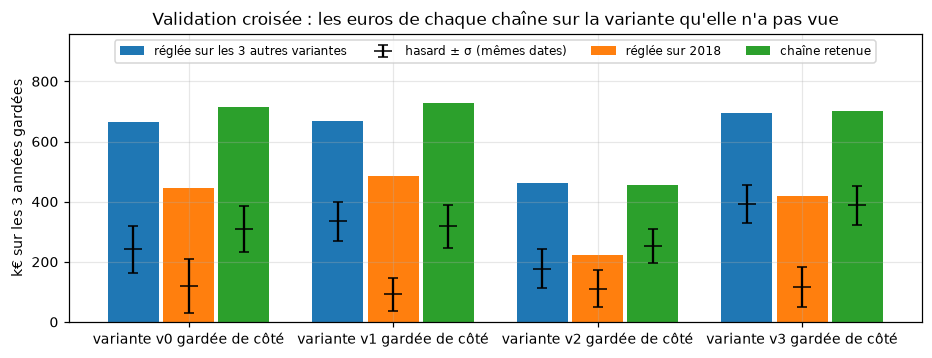

In [13]:
noms_c = ["réglée sur les 3 autres variantes", "réglée sur 2018", "chaîne retenue"]
couleurs = ["tab:blue", "tab:orange", "tab:green"]
plis_ = sorted(tcv.pli.unique())
fig, ax = plt.subplots()
for j, (c, coul) in enumerate(zip(noms_c, couleurs)):
    xs = np.arange(len(plis_)) + (j - 1) * 0.27
    ls = [next(x for x in lpli if x["pli"] == v and x["règle"] == f"pli {v} : {c} → 3 années de {v}") for v in plis_]
    ax.bar(xs, [x["euros"] / 1e3 for x in ls], 0.25, color=coul, label=c)
    ax.errorbar(xs, [x["hasard (€)"] / 1e3 for x in ls], yerr=[x["σ (€)"] / 1e3 for x in ls], fmt="_", color="k",
                ms=12, capsize=3, label="hasard ± σ (mêmes dates)" if j == 0 else None)
ax.set_xticks(range(len(plis_)), [f"variante {v} gardée de côté" for v in plis_])
ax.set_ylabel("k€ sur les 3 années gardées")
ax.set_title("Validation croisée : les euros de chaque chaîne sur la variante qu'elle n'a pas vue")
ax.set_ylim(0, ax.get_ylim()[1] * 1.25)
ax.legend(fontsize=8, loc="upper center", ncol=4)
plt.show()

**Ce qu'on regarde.** Pour chaque variante gardée de côté : la barre bleue est la chaîne réglée sans elle, l'orange la chaîne
réglée sur 2018, la verte la chaîne retenue ; le trait noir est le hasard (mêmes dates, conduites tirées au
hasard) de chaque chaîne, ± σ. L'orange est la plus basse partout ; bleue et verte sont proches, la verte
devant dans 3 variantes sur 4, de peu (moins d'un σ).

### Ce qu'on retient de la validation croisée

- **Régler sur les années simulées tient hors échantillon.** Sur les 12 années gardées de côté, la chaîne
  réglée sur les autres variantes fait 2 489 178 € (z +9,9) contre 1 574 392 € (z +8,2) pour la chaîne
  réglée sur 2018, et la bat dans les 4 plis. Le score de la partie 3, mesuré sur les années qui ont servi
  à régler, n'était optimiste que de 7 %.
- **Presque tout ce gain vient du regroupement.** La chaîne retenue (les réglages de 2018, sans le
  regroupement) fait autant : 2 604 480 € (z +9,9), devant la chaîne du pli dans 3 plis sur 4. Les autres
  réglages pris sur les années simulées (CUSUM, combinaison, carte) ne font pas mieux, hors échantillon,
  que ceux de 2018. Réserve : la décision de ne pas regrouper a vu ces 12 années ; mais aucun des 4 plis,
  qui ne les voyait pas toutes, n'a choisi un rayon de 100 m ou plus.
- **Les réglages sont mal déterminés, l'argent un peu mieux.** Les 4 plis choisissent des CUSUM, des
  combinaisons et des cartes différents ; sur 2018, leurs scores vont de 118 872 à 154 001 €, un écart
  de 1,7 σ du hasard d'une année. Une différence de quelques milliers d'euros sur 2018 entre deux
  chaînes ne dit donc rien sur laquelle est meilleure.
- Rien n'est dit ici sur 2019 : aucune donnée de 2019 n'a été utilisée.

## Résultats

In [14]:
noms = {0: "final regle 2018 note 2018", 1: "final regle simulees note 2018", 2: "final regle 2018 note simulees",
        3: "final regle simulees note simulees"}
for i, v in noms.items():
    x = lf[i]
    r_ = Res.ajouter("13", v, **Ch.colonnes_resultats(x), fausses_detecteur=x["fausses : détecteur"],
                     fausses_localisation=x["fausses : localisation"], annees=12 if v.endswith("simulees") else 1)
afficher(r_.set_index("version").drop(columns="etape").dropna(how="all", axis=1), 1)

,alarmes,fausses,euros,trouvees,repetees,hasard_euros,hasard_sigma,z,fausses_detecteur,fausses_localisation,annees
version,,,,,,,,,,,
final regle 2018 note 2018,15,2,151681,13,0,22767,22537,5.7,2,0,1
final regle simulees note 2018,38,11,140422,13,14,50393,21104,4.3,1,10,1
final regle 2018 note simulees,181,103,1574392,75,3,438429,138796,8.2,57,46,12
final regle simulees note simulees,582,213,2674382,127,242,1259675,135751,10.4,79,134,12


Les lignes des parties 6 et 7 :

In [15]:
for v, x in {"retenue sans regroupement note 2018": lr[1], "retenue sans regroupement note simulees": lr[3]}.items():
    r_ = Res.ajouter("13", v, **Ch.colonnes_resultats(x), fausses_detecteur=x["fausses : détecteur"],
                     fausses_localisation=x["fausses : localisation"], annees=12 if v.endswith("simulees") else 1)

for v, x in {"cv chaine du pli note 12 annees gardees": lens[0], "cv regle 2018 note 12 annees gardees": lens[1],
             "cv retenue note 12 annees gardees": lens[2]}.items():
    r_ = Res.ajouter("13", v, **Ch.colonnes_resultats(x), fausses_detecteur=x["fausses : détecteur"],
                     fausses_localisation=x["fausses : localisation"], annees=12)
afficher(r_.set_index("version").drop(columns="etape").dropna(how="all", axis=1).tail(5), 1)

,alarmes,fausses,euros,trouvees,repetees,hasard_euros,hasard_sigma,z,fausses_detecteur,fausses_localisation,annees
version,,,,,,,,,,,
retenue sans regroupement note 2018,44,8,148681,13,23,42302,22568,4.7,3,5,1
retenue sans regroupement note simulees,672,282,2604480,132,258,1268026,135065,9.9,133,149,12
cv chaine du pli note 12 annees gardees,539,229,2489178,127,183,1145805,135509,9.9,119,110,12
cv regle 2018 note 12 annees gardees,181,103,1574392,75,3,438429,138796,8.2,57,46,12
cv retenue note 12 annees gardees,672,282,2604480,132,258,1268026,135065,9.9,133,149,12


## À retenir

- **L'inventaire** : presque tous les réglages qui changent les alarmes avaient été choisis en regardant
  2018, ou fixés sans grille. Les σ des deux cartes, PART_NETTE et les seuils qui ne servent qu'à classer ne
  changent pas les alarmes (vérifié pour les σ).
- **Réglée sur les simulées**, la chaîne est très différente : CUSUM de pression peu sensible (8/6), carte
  de pression, confirmation des alarmes de débit, **pas de regroupement**.
- **Sur 2018**, elle rapporte 140 422 € contre 151 681 € : **−11 259 €, −0,50 σ**, avec les mêmes 13
  fuites et 11 fausses alarmes au lieu de 2. Aucun réglage pris seul ne gagne sur 2018 ; aucun ne perd plus
  de 0,8 σ.
- **Sur les simulées**, elle rapporte 70 % de plus, surtout parce qu'elle ne regroupe pas : le regroupement
  à 300 m y coûte 20 à 40 % et fait perdre des fuites de toutes les tailles.
- **Verdict** : avoir réglé la chaîne sur 2018 ne l'a pas rendue mauvaise ailleurs, sauf pour le
  regroupement, adopté pour le z de 2018 et qui coûte cher dès qu'une année a plus de fuites. Les autres
  écarts sont dans le bruit : 2018 seule ne peut pas les départager, et plusieurs choix des simulées
  changent quand on retire une variante.
- Les euros « réglé sur les simulées → simulées » sont dans l'échantillon : ils surestiment ce que
  donnerait une nouvelle année simulée.